# Synthetic Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy.special import expit  # sigmoid function

np.random.seed(42)

In [2]:
# Top 6 features
TOP_FEATURES = {
    'hemo': {'name': 'Hemoglobin', 'unit': 'g/dL', 'low': (12, 17), 'high': (3, 9)},
    'sc': {'name': 'Serum Creatinine', 'unit': 'mg/dL', 'low': (0.5, 1.2), 'high': (2.5, 15)},
    'bu': {'name': 'Blood Urea', 'unit': 'mg/dL', 'low': (10, 45), 'high': (60, 200)},
    'al': {'name': 'Albumin', 'unit': 'g/dL', 'low': (3.5, 5.5), 'high': (0.5, 2.5)},
    'sg': {'name': 'Specific Gravity', 'unit': '', 'low': (1.015, 1.025), 'high': (1.005, 1.012)},
    'pcv': {'name': 'Packed Cell Volume', 'unit': '%', 'low': (38, 54), 'high': (15, 32)}
}

In [3]:
def generate_progression_curve(start, end, num_points, noise_level=0.05, scenario='worsening'):
    """
    Parameters:
    - start: starting value
    - end: ending value
    - num_points: number of time points
    - noise_level: amount of random noise (0-1)
    - scenario: 'worsening', 'improving', or 'neither improving nor worsening'
    """
    t = np.linspace(0, 1, num_points)

    if scenario == 'worsening':
        progress = expit(8 * (t - 0.5))
    elif scenario == 'improving':
        progress = expit(8 * (t - 0.5))
    else:
        progress = t + np.random.uniform(-0.1, 0.1, num_points)
        progress = np.clip(progress, 0, 1)

    values = start + (end - start) * progress
    noise = np.random.normal(0, noise_level * abs(end - start), num_points)
    values = values + noise

    return values

In [4]:
def calculate_risk_probability(features_dict):
    """
    Lower hemoglobin, albumin, pcv = higher risk
    Higher creatinine, urea = higher risk
    Lower specific gravity = higher risk
    """
    # Feature weights based on clinical importance
    weights = {
        'hemo': 0.20,
        'sc': 0.25,
        'bu': 0.20,
        'al': 0.15,
        'sg': 0.10,
        'pcv': 0.10
    }

    risk = 0

    for key, value in features_dict.items():
        feature_info = TOP_FEATURES[key]
        low_range = feature_info['low']
        high_range = feature_info['high']

        low_avg = np.mean(low_range)
        high_avg = np.mean(high_range)

        if key in ['hemo', 'al', 'pcv']:
            feature_risk = 1 - np.clip((value - high_avg) / (low_avg - high_avg), 0, 1)
        elif key == 'sg':
            feature_risk = 1 - np.clip((value - high_range[1]) / (low_avg - high_range[1]), 0, 1)
        else:
            feature_risk = np.clip((value - low_avg) / (high_avg - low_avg), 0, 1)

        risk += feature_risk * weights[key]

    return np.clip(risk, 0, 1)

In [5]:
def get_risk_label(risk_prob):
    """Convert risk probability to categorical label."""
    if risk_prob < 0.4:
        return 'low'
    elif risk_prob < 0.7:
        return 'medium'
    else:
        return 'high'

In [6]:
def generate_synthetic_ckd_data(num_patients=500, num_timepoints=12, start_date='2023-01-01'):
    """
    Parameters:
    - num_patients: number of unique patients
    - num_timepoints: number of monthly observations per patient
    - start_date: starting date for timeline
    """
    print("Generating synthetic CKD temporal data...")

    all_records = []
    base_date = datetime.strptime(start_date, '%Y-%m-%d')

    scenarios = np.random.choice(
        ['worsening', 'improving', 'neither improving nor worsening'],
        size=num_patients,
        p=[0.40, 0.35, 0.25]
    )

    for patient_id in range(1, num_patients + 1):
        scenario = scenarios[patient_id - 1]

        if scenario == 'worsening':
            start_risk_level = np.random.choice(['low', 'medium'], p=[0.6, 0.4])
        elif scenario == 'improving':
            start_risk_level = np.random.choice(['medium', 'high'], p=[0.4, 0.6])
        else:
            start_risk_level = np.random.choice(['low', 'medium', 'high'], p=[0.33, 0.34, 0.33])

        patient_features = {}

        for feature_key, feature_info in TOP_FEATURES.items():
            low_range = feature_info['low']
            high_range = feature_info['high']

            if scenario == 'worsening':
                # For worsening patients: healthy values → unhealthy values
                # For hemo, al, pcv: HIGH values are healthy, LOW values are unhealthy
                # For sc, bu: LOW values are healthy, HIGH values are unhealthy
                # For sg: HIGH values are healthy, LOW values are unhealthy

                if feature_key in ['hemo', 'al', 'pcv', 'sg']:
                    if start_risk_level == 'low':
                        start_val = np.random.uniform(low_range[0], low_range[1])
                        end_val = np.random.uniform(high_range[0], high_range[1])
                    else:
                        mid_low = np.mean(low_range)
                        mid_high = np.mean(high_range)
                        start_val = np.random.uniform(mid_low - 0.3 * (low_range[1] - low_range[0]),
                                                       mid_low + 0.3 * (low_range[1] - low_range[0]))
                        end_val = np.random.uniform(mid_high - 0.3 * (high_range[1] - high_range[0]),
                                                     mid_high + 0.3 * (high_range[1] - high_range[0]))
                else:
                    if start_risk_level == 'low':
                        start_val = np.random.uniform(low_range[0], low_range[1])
                        end_val = np.random.uniform(high_range[0], high_range[1])
                    else:
                        mid_low = np.mean(low_range)
                        mid_high = np.mean(high_range)
                        start_val = np.random.uniform(mid_low - 0.3 * (low_range[1] - low_range[0]),
                                                       mid_low + 0.3 * (low_range[1] - low_range[0]))
                        end_val = np.random.uniform(mid_high - 0.3 * (high_range[1] - high_range[0]),
                                                     mid_high + 0.3 * (high_range[1] - high_range[0]))

            elif scenario == 'improving':
                # For improving patients: unhealthy values → healthy values
                # For hemo, al, pcv: LOW values are unhealthy, HIGH values are healthy
                # For sc, bu: HIGH values are unhealthy, LOW values are healthy
                # For sg: LOW values are unhealthy, HIGH values are healthy

                if feature_key in ['hemo', 'al', 'pcv', 'sg']:
                    if start_risk_level == 'high':
                        start_val = np.random.uniform(high_range[0], high_range[1])
                        end_val = np.random.uniform(low_range[0], low_range[1])
                    else:
                        mid_low = np.mean(low_range)
                        mid_high = np.mean(high_range)
                        start_val = np.random.uniform(mid_high - 0.3 * (high_range[1] - high_range[0]),
                                                       mid_high + 0.3 * (high_range[1] - high_range[0]))
                        end_val = np.random.uniform(mid_low - 0.3 * (low_range[1] - low_range[0]),
                                                     mid_low + 0.3 * (low_range[1] - low_range[0]))
                else:
                    if start_risk_level == 'high':
                        start_val = np.random.uniform(high_range[0], high_range[1])
                        end_val = np.random.uniform(low_range[0], low_range[1])
                    else:
                        mid_low = np.mean(low_range)
                        mid_high = np.mean(high_range)
                        start_val = np.random.uniform(mid_high - 0.3 * (high_range[1] - high_range[0]),
                                                       mid_high + 0.3 * (high_range[1] - high_range[0]))
                        end_val = np.random.uniform(mid_low - 0.3 * (low_range[1] - low_range[0]),
                                                     mid_low + 0.3 * (low_range[1] - low_range[0]))

            else:  # neither improving nor worsening
                if start_risk_level == 'low':
                    range_vals = low_range
                elif start_risk_level == 'high':
                    range_vals = high_range
                else:
                    range_vals = (np.mean(low_range + high_range) / 2,
                                  np.mean(low_range + high_range) / 2)

                start_val = np.random.uniform(range_vals[0], range_vals[1])
                end_val = start_val + np.random.uniform(-0.2, 0.2) * (range_vals[1] - range_vals[0])

            patient_features[feature_key] = generate_progression_curve(
                start_val, end_val, num_timepoints, noise_level=0.05, scenario=scenario
            )

        for t in range(num_timepoints):
            record_date = base_date + timedelta(days=30 * t)

            features_at_t = {key: round(patient_features[key][t], 2) for key in TOP_FEATURES.keys()}
            risk_prob = calculate_risk_probability(features_at_t)

            record = {
                'patient_id': f'P{patient_id:03d}',
                'date': record_date.strftime('%Y-%m-%d'),
                **features_at_t,
                'risk_probability': round(risk_prob, 3),
                'risk_label': get_risk_label(risk_prob),
                'scenario': scenario
            }

            all_records.append(record)

        if patient_id % 100 == 0:
            print(f"  Generated data for {patient_id}/{num_patients} patients...")

    df = pd.DataFrame(all_records)
    print(f"\nGenerated {len(df)} records for {num_patients} patients")
    print(f"Timepoints per patient: {num_timepoints}")

    return df

In [7]:
def analyze_dataset(df):
    """Print summary statistics of the generated dataset."""
    print("\n--- DATASET SUMMARY ---")

    print(f"\nShape: {df.shape}")
    print(f"Unique patients: {df['patient_id'].nunique()}")
    print(f"Date range: {df['date'].min()} to {df['date'].max()}")

    print("\n--- Scenario Distribution ---")
    print(df.groupby('scenario')['patient_id'].nunique())

    print("\n--- Risk Label Distribution ---")
    print(df['risk_label'].value_counts().sort_index())

    print("\n--- Feature Statistics ---")
    feature_cols = ['hemo', 'sc', 'bu', 'al', 'sg', 'pcv']
    print(df[feature_cols].describe().round(2))

In [8]:
def visualize_patient_trajectory(df, patient_id='P001'):
    """Visualize temporal progression for a single patient."""
    patient_data = df[df['patient_id'] == patient_id].sort_values('date')

    if len(patient_data) == 0:
        print(f"Patient {patient_id} not found!")
        return

    scenario = patient_data['scenario'].iloc[0]

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Plot 1: Risk probability over time
    axes[0].plot(patient_data['date'], patient_data['risk_probability'],
                 marker='o', linewidth=2, markersize=8, color='purple')
    axes[0].axhline(y=0.4, color='green', linestyle='--', alpha=0.5, label='Low/Medium threshold')
    axes[0].axhline(y=0.7, color='red', linestyle='--', alpha=0.5, label='Medium/High threshold')
    axes[0].set_xlabel('Date', fontsize=12)
    axes[0].set_ylabel('Risk Probability', fontsize=12)
    axes[0].set_title(f'Patient {patient_id} - Risk Progression ({scenario.capitalize()} Scenario)',
                      fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(0, 1)
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

    # Plot 2: Clinical features over time
    feature_cols = ['hemo', 'sc', 'bu', 'al']
    colors = ['red', 'blue', 'green', 'orange']

    for col, color in zip(feature_cols, colors):
        axes[1].plot(patient_data['date'], patient_data[col],
                     marker='o', label=TOP_FEATURES[col]['name'],
                     linewidth=2, markersize=6, color=color)

    axes[1].set_xlabel('Date', fontsize=12)
    axes[1].set_ylabel('Feature Values', fontsize=12)
    axes[1].set_title('Clinical Features Over Time', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

    plt.tight_layout()
    plt.savefig(f'patient_{patient_id}_trajectory.png', dpi=300, bbox_inches='tight')
    print(f"\nSaved visualization to 'patient_{patient_id}_trajectory.png'")
    plt.show()

In [9]:
def visualize_feature_thresholds():
    """Visualize risk thresholds for all features."""
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for idx, (key, info) in enumerate(TOP_FEATURES.items()):
        ax = axes[idx]

        low_range = info['low']
        high_range = info['high']

        ax.barh([0], [low_range[1] - low_range[0]], left=low_range[0],
                color='green', alpha=0.6, label='Low Risk', height=0.4)
        ax.barh([0], [high_range[1] - high_range[0]], left=high_range[0],
                color='red', alpha=0.6, label='High Risk', height=0.4)

        ax.set_yticks([])
        ax.set_xlabel(f'{info["unit"]}', fontsize=10)
        ax.set_title(f'{info["name"]}\n({key})', fontsize=11, fontweight='bold')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3, axis='x')

    plt.suptitle('CKD Risk Thresholds for Top 6 Features', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('feature_thresholds.png', dpi=300, bbox_inches='tight')
    print("\nSaved thresholds visualization to 'feature_thresholds.png'")
    plt.show()

Generating synthetic CKD temporal data...
  Generated data for 100/500 patients...
  Generated data for 200/500 patients...
  Generated data for 300/500 patients...
  Generated data for 400/500 patients...
  Generated data for 500/500 patients...

Generated 6000 records for 500 patients
Timepoints per patient: 12

--- DATASET SUMMARY ---

Shape: (6000, 11)
Unique patients: 500
Date range: 2023-01-01 to 2023-11-27

--- Scenario Distribution ---
scenario
improving                          162
neither improving nor worsening    131
worsening                          207
Name: patient_id, dtype: int64

--- Risk Label Distribution ---
risk_label
high      2225
low       2569
medium    1206
Name: count, dtype: int64

--- Feature Statistics ---
          hemo       sc       bu       al       sg      pcv
count  6000.00  6000.00  6000.00  6000.00  6000.00  6000.00
mean      9.89     4.51    75.17     2.86     0.97    33.58
std       3.76     3.74    47.25     1.32     0.14    10.69
min       2.

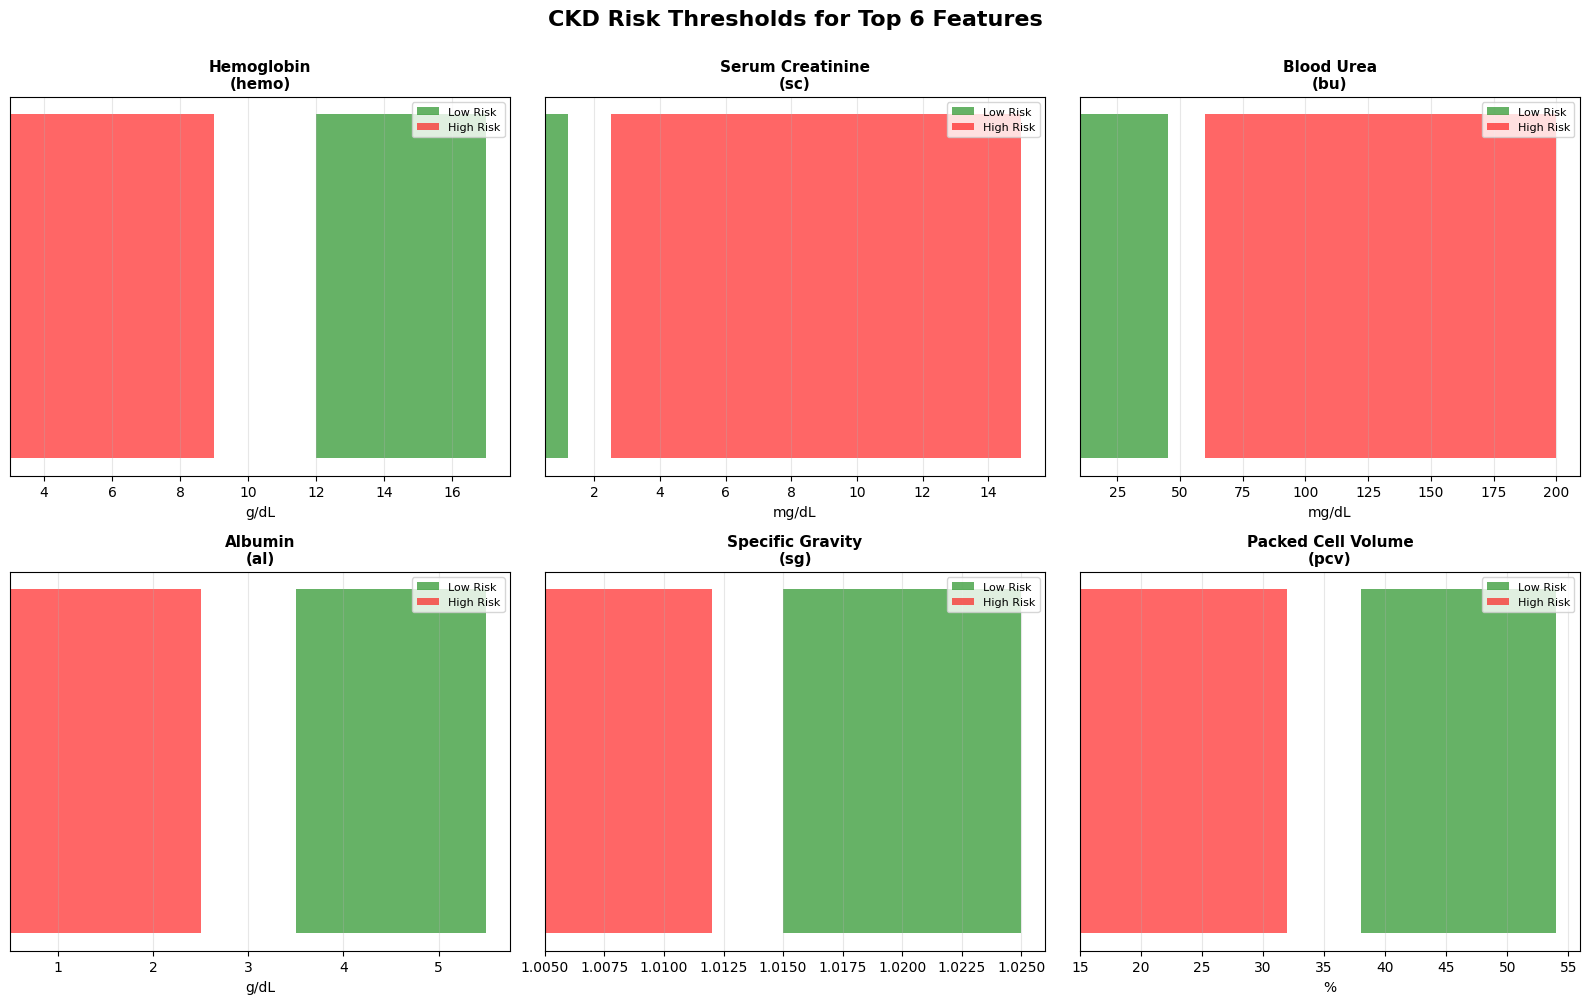


--- VISUALIZING EXAMPLE PATIENTS ---

Generating plot for worsening patient: P001

Saved visualization to 'patient_P001_trajectory.png'


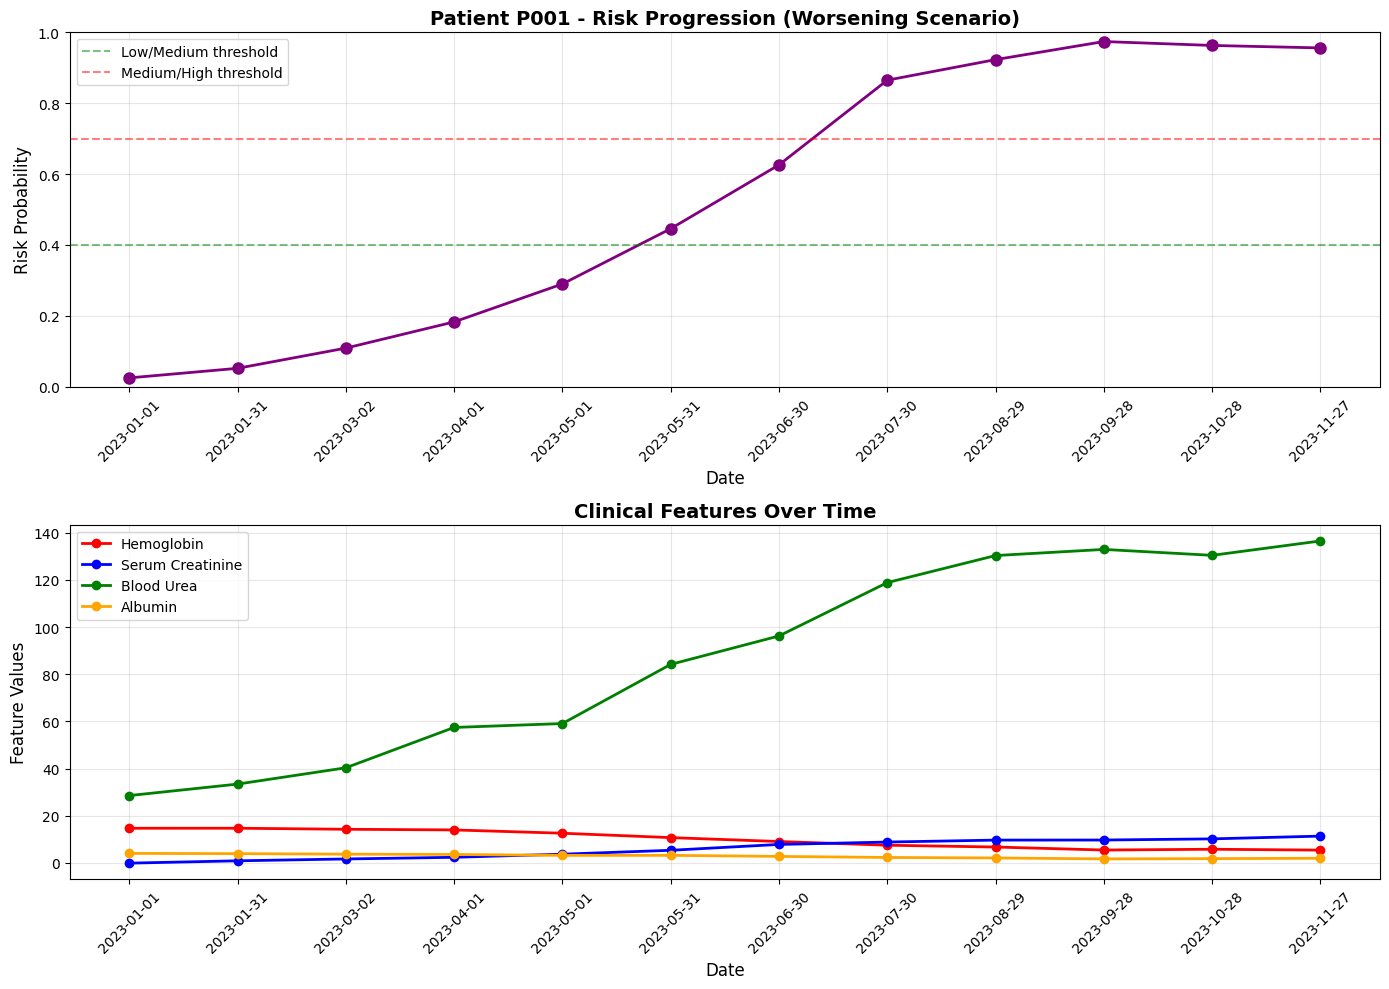


Generating plot for improving patient: P003

Saved visualization to 'patient_P003_trajectory.png'


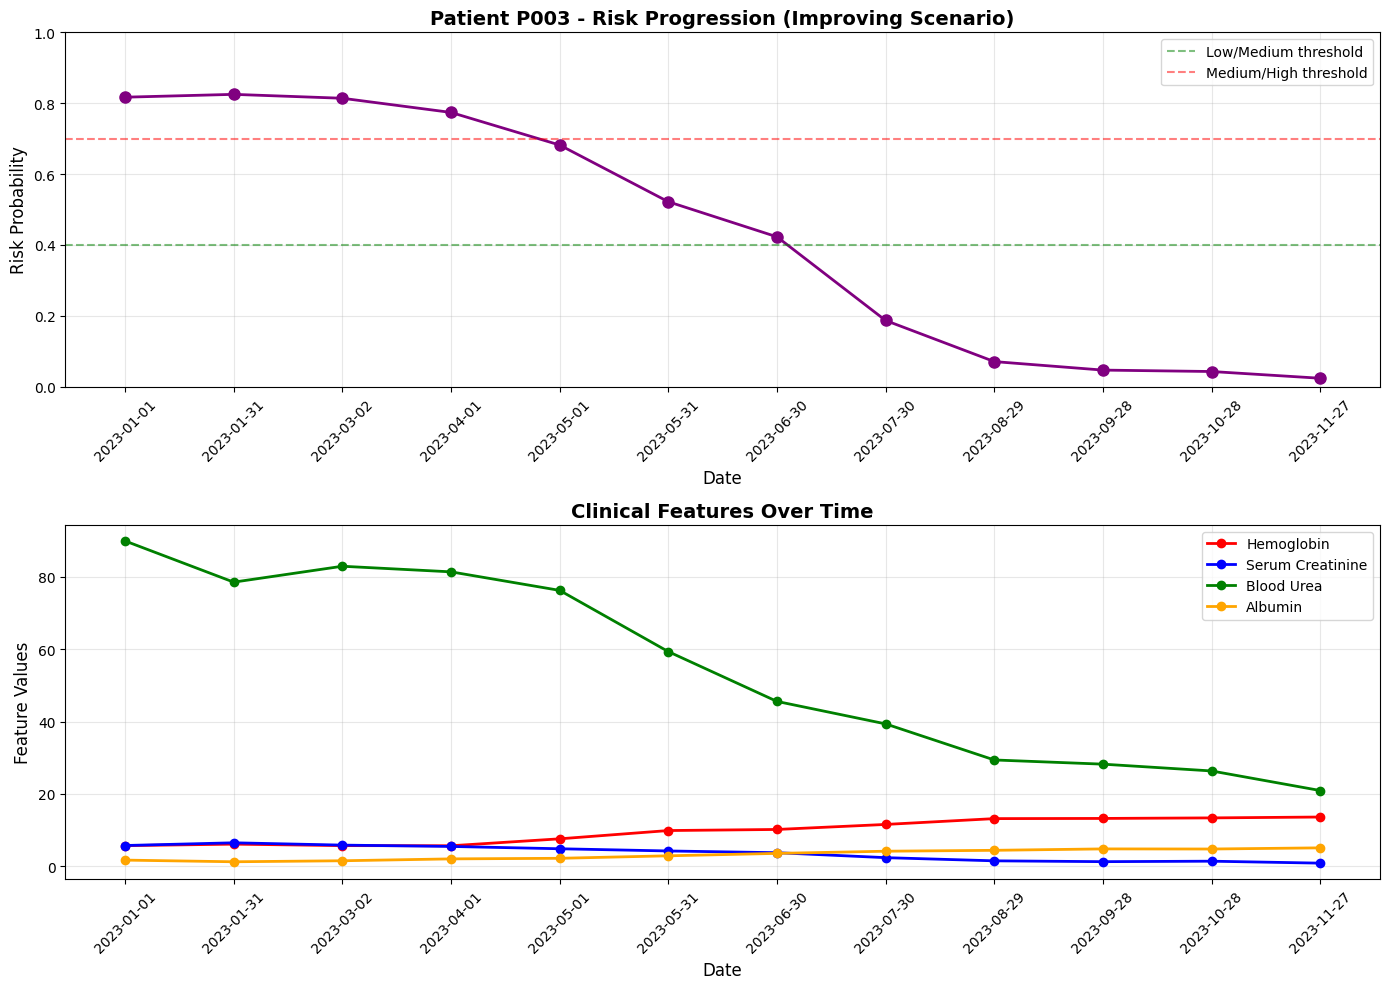


Generating plot for neither improving nor worsening patient: P002

Saved visualization to 'patient_P002_trajectory.png'


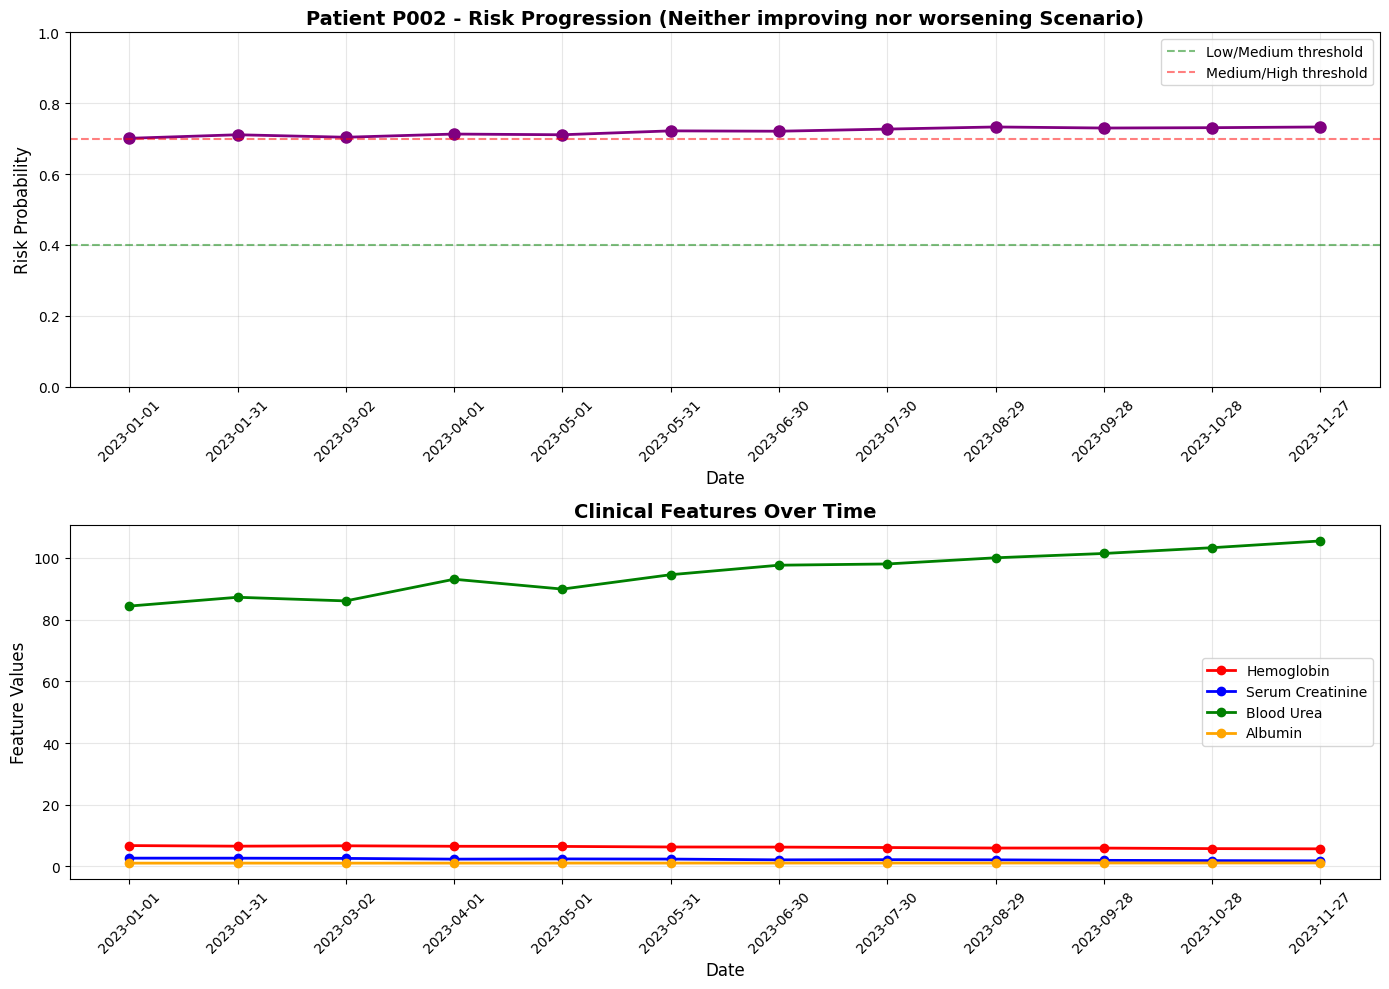


--- ALL DONE! ---


In [10]:
if __name__ == "__main__":
    # Generate synthetic dataset
    df_synthetic = generate_synthetic_ckd_data(
        num_patients=500,
        num_timepoints=12,
        start_date='2023-01-01'
    )

    # Analyze dataset
    analyze_dataset(df_synthetic)

    # Save to CSV
    output_file = 'ckd_temporal_synthetic_data.csv'
    df_synthetic.to_csv(output_file, index=False)
    print(f"\nSaved dataset to '{output_file}'")

    # Visualize thresholds
    visualize_feature_thresholds()

    # Visualize example patients (one from each scenario)
    print("\n--- VISUALIZING EXAMPLE PATIENTS ---")

    for scenario in ['worsening', 'improving', 'neither improving nor worsening']:
        example_patient = df_synthetic[df_synthetic['scenario'] == scenario]['patient_id'].iloc[0]
        print(f"\nGenerating plot for {scenario} patient: {example_patient}")
        visualize_patient_trajectory(df_synthetic, example_patient)

    print("\n--- ALL DONE! ---")

In [11]:
print("\n--- Sample Records ---")
print(df_synthetic.head(35))


--- Sample Records ---
   patient_id        date   hemo     sc      bu    al    sg    pcv  \
0        P001  2023-01-01  14.71  -0.08   28.56  4.05  1.02  45.96   
1        P001  2023-01-31  14.72   0.91   33.43  3.95  1.02  43.63   
2        P001  2023-03-02  14.28   1.69   40.34  3.73  1.02  42.91   
3        P001  2023-04-01  14.00   2.40   57.44  3.60  1.02  41.74   
4        P001  2023-05-01  12.60   3.72   59.09  3.22  1.02  39.56   
5        P001  2023-05-31  10.74   5.37   84.17  3.22  1.02  37.08   
6        P001  2023-06-30   9.09   7.85   96.22  2.77  1.02  33.29   
7        P001  2023-07-30   7.52   8.86  118.84  2.33  1.01  31.65   
8        P001  2023-08-29   6.75   9.69  130.31  2.12  1.01  29.97   
9        P001  2023-09-28   5.48   9.72  132.91  1.73  1.01  26.84   
10       P001  2023-10-28   5.81  10.21  130.40  1.83  1.01  28.08   
11       P001  2023-11-27   5.44  11.38  136.50  1.99  1.01  27.89   
12       P002  2023-01-01   6.77   2.70   84.38  1.08  1.01  17.52

# Model Selection

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
import pickle
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [67]:
def prepare_datasets(df):
    print("\nPreparing datasets...")

    feature_cols = ['hemo', 'sc', 'bu', 'al', 'sg', 'pcv']

    print("Risk dataset: using current timestamp only")
    X_risk = df[feature_cols].values
    y_risk = df['risk_label'].values

    print(f"Risk samples: {len(X_risk)}")
    print(f"Risk distribution: {dict(zip(*np.unique(y_risk, return_counts=True)))}")

    print("\nScenario dataset: using all previous timestamps + current")

    X_scenario_list = []
    y_scenario_list = []
    max_len = 0

    for patient_id in df['patient_id'].unique():
        patient_data = df[df['patient_id'] == patient_id].sort_values('date').reset_index(drop=True)

        if len(patient_data) < 2:
            continue

        for i in range(1, len(patient_data)):
            all_previous = patient_data.iloc[:i]
            current = patient_data.iloc[i]

            previous_features = []
            for _, row in all_previous.iterrows():
                previous_features.extend(row[feature_cols].values)

            current_features = current[feature_cols].values.tolist()

            combined_features = previous_features + current_features

            X_scenario_list.append(combined_features)
            y_scenario_list.append(current['scenario'])

            if len(combined_features) > max_len:
                max_len = len(combined_features)

    X_scenario_padded = []
    for features in X_scenario_list:
        padded = features + [np.nan] * (max_len - len(features))
        X_scenario_padded.append(padded)

    X_scenario = np.array(X_scenario_padded)
    y_scenario = np.array(y_scenario_list)

    print(f"Scenario samples: {len(X_scenario)}")
    print(f"Scenario distribution: {dict(zip(*np.unique(y_scenario, return_counts=True)))}")
    print(f"Scenario features: {X_scenario.shape[1]} (padded to max length)")

    return X_risk, y_risk, X_scenario, y_scenario, feature_cols

In [68]:
def introduce_missing_data(X, missing_rate=0.15):
    X_missing = X.copy()
    n_samples, n_features = X.shape

    n_missing = int(n_samples * n_features * missing_rate)
    missing_indices = np.random.choice(n_samples * n_features, n_missing, replace=False)

    for idx in missing_indices:
        row = idx // n_features
        col = idx % n_features
        X_missing[row, col] = np.nan

    missing_count = np.isnan(X_missing).sum()
    print(f"Introduced {missing_count} missing values ({missing_count/(n_samples*n_features)*100:.1f}%)\n")

    return X_missing

In [69]:
def get_models():
    models = {
        'Logistic Regression': Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(max_iter=1000, random_state=42))
        ]),

        'SVC': Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
            ('classifier', SVC(kernel='rbf', probability=True, random_state=42))
        ]),

        'Decision Tree': Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('classifier', DecisionTreeClassifier(max_depth=10, random_state=42))
        ]),

        'Random Forest': Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
        ]),

        'XGBoost': Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('classifier', XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                        random_state=42, eval_metric='mlogloss'))
        ]),

        'LightGBM': Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('classifier', LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                         random_state=42, verbose=-1))
        ])
    }

    return models

In [70]:
def train_and_evaluate(X, y, target_name='risk_label'):
    print(f"\nTraining models to predict: {target_name}\n")

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    print(f"Label encoding: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
    print(f"Missing values in train: {np.isnan(X_train).sum()}")
    print(f"Missing values in test: {np.isnan(X_test).sum()}\n")

    models = get_models()
    results = []
    trained_models = {}

    for model_name, model_pipeline in models.items():
        print(f"Training {model_name}")

        model_pipeline.fit(X_train, y_train)
        y_pred = model_pipeline.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        f1_micro = f1_score(y_test, y_pred, average='micro')
        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')

        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1 Score (Macro): {f1_macro:.4f}\n")

        results.append({
            'Model': model_name,
            'Accuracy': accuracy,
            'F1_Micro': f1_micro,
            'F1_Macro': f1_macro,
            'F1_Weighted': f1_weighted
        })

        trained_models[model_name] = {
            'pipeline': model_pipeline,
            'y_test': y_test,
            'y_pred': y_pred
        }

    results_df = pd.DataFrame(results).sort_values('F1_Macro', ascending=False)

    print("Model comparison summary:")
    print(results_df.to_string(index=False))
    print()

    return results_df, trained_models, label_encoder

In [71]:
if __name__ == "__main__":
    print("CKD Risk & Scenario Prediction Model Training")
    print("Risk: Current timestamp only")
    print("Scenario: All previous timestamps + current\n")

    print("Loading data...")
    df = pd.read_csv('ckd_temporal_synthetic_data.csv')
    print(f"Loaded {len(df)} records\n")

    X_risk, y_risk, X_scenario, y_scenario, feature_cols = prepare_datasets(df)

    print("\nSimulating missing data...")
    X_risk_missing = introduce_missing_data(X_risk.copy(), missing_rate=0.15)
    X_scenario_missing = introduce_missing_data(X_scenario.copy(), missing_rate=0.15)

    print("Training models for RISK prediction (current timestamp only)")
    results_risk, models_risk, encoder_risk = train_and_evaluate(
        X_risk_missing, y_risk, target_name='Risk_Label'
    )

    print("Training models for SCENARIO prediction (all previous + current)")
    results_scenario, models_scenario, encoder_scenario = train_and_evaluate(
        X_scenario_missing, y_scenario, target_name='Scenario'
    )

    best_risk_name = results_risk.iloc[0]['Model']
    best_scenario_name = results_scenario.iloc[0]['Model']

    best_risk_model = models_risk[best_risk_name]['pipeline']
    best_scenario_model = models_scenario[best_scenario_name]['pipeline']

    model_package = {
        'model_risk': best_risk_model,
        'model_scenario': best_scenario_model,
        'encoder_risk': encoder_risk,
        'encoder_scenario': encoder_scenario,
        'features': feature_cols,
        'best_risk_model_name': best_risk_name,
        'best_scenario_model_name': best_scenario_name,
        'risk_accuracy': results_risk.iloc[0]['Accuracy'],
        'scenario_accuracy': results_scenario.iloc[0]['Accuracy'],
        'risk_f1_macro': results_risk.iloc[0]['F1_Macro'],
        'scenario_f1_macro': results_scenario.iloc[0]['F1_Macro']
    }

    with open('best_ckd_model.pkl', 'wb') as f:
        pickle.dump(model_package, f)

    print("\nSaved best models to best_ckd_model.pkl")
    print(f"\nBest Risk Model: {best_risk_name}")
    print(f"Accuracy: {results_risk.iloc[0]['Accuracy']:.4f}")
    print(f"F1 Score: {results_risk.iloc[0]['F1_Macro']:.4f}")

    print(f"\nBest Scenario Model: {best_scenario_name}")
    print(f"Accuracy: {results_scenario.iloc[0]['Accuracy']:.4f}")
    print(f"F1 Score: {results_scenario.iloc[0]['F1_Macro']:.4f}")

    print("\nTraining complete")

CKD Risk & Scenario Prediction Model Training
Risk: Current timestamp only
Scenario: All previous timestamps + current

Loading data...
Loaded 6000 records


Preparing datasets...
Risk dataset: using current timestamp only
Risk samples: 6000
Risk distribution: {'high': np.int64(2225), 'low': np.int64(2569), 'medium': np.int64(1206)}

Scenario dataset: using all previous timestamps + current
Scenario samples: 5500
Scenario distribution: {np.str_('improving'): np.int64(1782), np.str_('neither improving nor worsening'): np.int64(1441), np.str_('worsening'): np.int64(2277)}
Scenario features: 72 (padded to max length)

Simulating missing data...
Introduced 5400 missing values (15.0%)

Introduced 199560 missing values (50.4%)

Training models for RISK prediction (current timestamp only)

Training models to predict: Risk_Label

Label encoding: {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}
Train size: 4800, Test size: 1200
Missing values in train: 4305
Missing values in tes

In [72]:
import pickle

saved = pickle.load(open('best_ckd_model.pkl', 'rb'))

model_risk = saved['model_risk']
model_scenario = saved['model_scenario']
encoder_risk = saved['encoder_risk']
encoder_scenario = saved['encoder_scenario']
features = saved['features']

risk_package = {
    'model': model_risk,
    'encoder': encoder_risk,
    'features': features,
    'model_name': saved['best_risk_model_name'],
    'accuracy': saved['risk_accuracy'],
    'f1_macro': saved['risk_f1_macro']
}

scenario_package = {
    'model': model_scenario,
    'encoder': encoder_scenario,
    'features': features,
    'model_name': saved['best_scenario_model_name'],
    'accuracy': saved['scenario_accuracy'],
    'f1_macro': saved['scenario_f1_macro']
}

with open('risk_model.pkl', 'wb') as f:
    pickle.dump(risk_package, f)

with open('scenario_model.pkl', 'wb') as f:
    pickle.dump(scenario_package, f)

print("Saved risk_model.pkl")
print("Saved scenario_model.pkl")

Saved risk_model.pkl
Saved scenario_model.pkl


# Input - Output

CKD PATIENT RISK PREDICTION

Patient ID (required): 024

--- TIMESTAMP 1 ---

Date (YYYY-MM-DD, required): 2025-01-12

Enter feature values (press Enter to skip):

HEMO - Hemoglobin (g/dL) [12-17]: 14.5
SC - Serum Creatinine (mg/dL) [0.6-1.2]: 0.8
BU - Blood Urea (mg/dL) [7-20]: 18
AL - Albumin (g/dL) [3.5-5.5]: 4.2
SG - Specific Gravity [1.005-1.030]: 1.020
PCV - Packed Cell Volume (%) [36-50]: 45

--- PREDICTION AFTER TIMESTAMP 1 ---

Low Risk: 0.0000 (0.00%)
Risk: LOW

Continue? (type 'no' to stop, Enter to continue): 

--- TIMESTAMP 2 ---

Date (YYYY-MM-DD, required): 2025-02-12

Enter feature values (press Enter to skip):

HEMO - Hemoglobin (g/dL) [12-17]: 13.8
SC - Serum Creatinine (mg/dL) [0.6-1.2]: 1.1
BU - Blood Urea (mg/dL) [7-20]: 28
AL - Albumin (g/dL) [3.5-5.5]: 4.0
SG - Specific Gravity [1.005-1.030]: 
PCV - Packed Cell Volume (%) [36-50]: 42

--- PREDICTION AFTER TIMESTAMP 2 ---

Low Risk: 0.0000 (0.00%)
Risk: LOW

Continue? (type 'no' to stop, Enter to continue): 

--- 

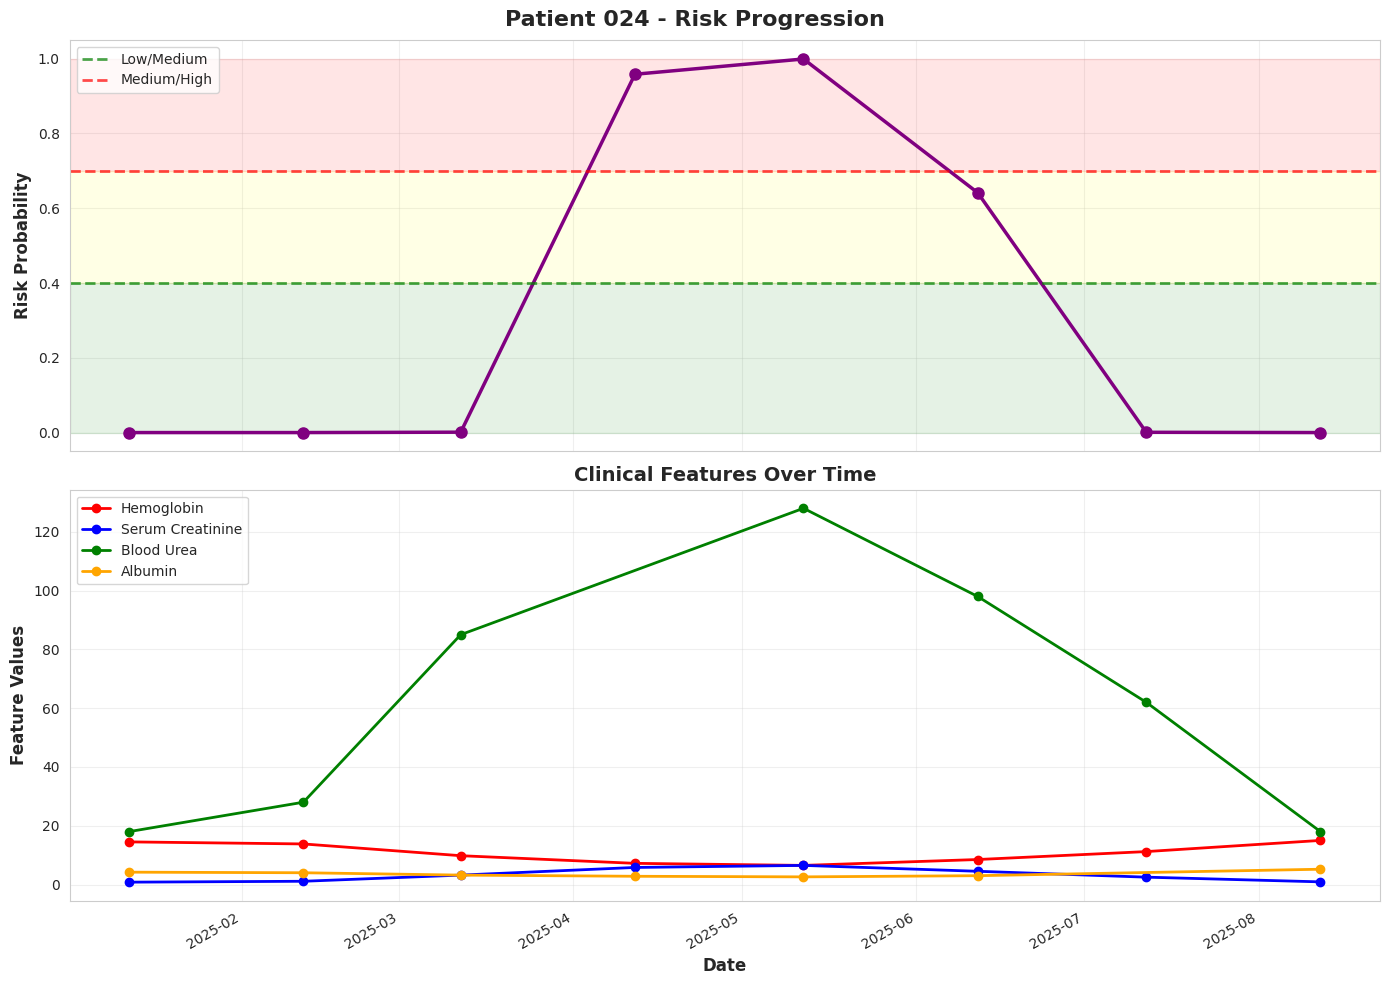


--- SESSION COMPLETE ---

Patient: 024
Timestamps: 8
Final Risk: 0.0000 (Low Risk)


In [75]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

risk_bundle = pickle.load(open('risk_model.pkl', 'rb'))

def _get(bundle, *keys, default=None):
    for k in keys:
        if k in bundle:
            return bundle[k]
    return default

model_risk   = _get(risk_bundle, 'model', 'model_risk')
encoder_risk = _get(risk_bundle, 'encoder', 'encoder_risk', default=None)
features     = _get(risk_bundle, 'features')

if features is None:
    raise ValueError("Could not infer feature list from risk_model.pkl. Include 'features' key.")

feature_desc = {
    'hemo': 'Hemoglobin (g/dL) [12-17]',
    'sc':   'Serum Creatinine (mg/dL) [0.6-1.2]',
    'bu':   'Blood Urea (mg/dL) [7-20]',
    'al':   'Albumin (g/dL) [3.5-5.5]',
    'sg':   'Specific Gravity [1.005-1.030]',
    'pcv':  'Packed Cell Volume (%) [36-50]'
}

timestamps_data = []
predictions_risk = []
dates = []

print("CKD PATIENT RISK PREDICTION\n")

while True:
    patient_id = input("Patient ID (required): ").strip()
    if patient_id:
        break
    print("Patient ID is required\n")

timestamp_num = 1
while True:
    print(f"\n--- TIMESTAMP {timestamp_num} ---\n")
    while True:
        date_input = input("Date (YYYY-MM-DD, required): ").strip()
        if date_input:
            try:
                date = datetime.strptime(date_input, '%Y-%m-%d')
                break
            except ValueError:
                print("Invalid date format. Use YYYY-MM-DD\n")
        else:
            print("Date is required\n")

    print("\nEnter feature values (press Enter to skip):\n")
    data = {}
    for f in features:
        label = feature_desc.get(f, f.upper())
        val = input(f"{f.upper()} - {label}: ").strip()
        if val:
            try:
                data[f] = float(val)
            except ValueError:
                data[f] = np.nan
        else:
            data[f] = np.nan

    timestamps_data.append(data)
    dates.append(date)

    X_risk = np.array([[data[f] for f in features]], dtype=float)
    risk_proba_vec = model_risk.predict_proba(X_risk)[0]
    if encoder_risk is not None:
        high_idx = list(encoder_risk.classes_).index('high')
        risk_prob = float(risk_proba_vec[high_idx])
        risk_pred_enc = model_risk.predict(X_risk)[0]
        risk_label = encoder_risk.inverse_transform([risk_pred_enc])[0]
    else:
        high_idx = -1
        risk_prob = float(risk_proba_vec[high_idx])
        risk_label = 'high' if risk_prob >= 0.5 else 'low'

    if risk_prob < 0.4:
        category = "Low Risk"
    elif risk_prob < 0.7:
        category = "Medium Risk"
    else:
        category = "High Risk"

    predictions_risk.append(risk_prob)

    print(f"\n--- PREDICTION AFTER TIMESTAMP {timestamp_num} ---\n")
    print(f"{category}: {risk_prob:.4f} ({risk_prob*100:.2f}%)")
    print(f"Risk: {risk_label.upper()}")

    cont = input("\nContinue? (type 'no' to stop, Enter to continue): ").strip().lower()
    if cont in ['no', 'stop', 'quit', 'exit']:
        break

    timestamp_num += 1

if len(timestamps_data) >= 2:
    print("\nCreating visualization\n")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle(f'Patient {patient_id} - Risk Progression', fontsize=16, fontweight='bold')

    ax1.plot(dates, predictions_risk, 'o-', color='purple', linewidth=2.5, markersize=8)
    ax1.axhline(0.4, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Low/Medium')
    ax1.axhline(0.7, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Medium/High')
    ax1.axhspan(0, 0.4, alpha=0.1, color='green')
    ax1.axhspan(0.4, 0.7, alpha=0.1, color='yellow')
    ax1.axhspan(0.7, 1.0, alpha=0.1, color='red')
    ax1.set_ylabel('Risk Probability', fontsize=12, fontweight='bold')
    ax1.set_ylim(-0.05, 1.05)
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_xticklabels([])

    ax2.set_title('Clinical Features Over Time', fontsize=14, fontweight='bold')
    colors_map = {'hemo': 'red', 'sc': 'blue', 'bu': 'green', 'al': 'orange'}
    names_map  = {'hemo': 'Hemoglobin', 'sc': 'Serum Creatinine', 'bu': 'Blood Urea', 'al': 'Albumin'}

    for f in ['hemo', 'sc', 'bu', 'al']:
        if f in features:
            values = [d[f] for d in timestamps_data]
            valid_idx = [i for i, v in enumerate(values) if not np.isnan(v)]
            if valid_idx:
                ax2.plot([dates[i] for i in valid_idx],
                         [values[i] for i in valid_idx],
                         'o-', color=colors_map.get(f, 'gray'),
                         linewidth=2, markersize=6, label=names_map.get(f, f.upper()))

    ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Feature Values', fontsize=12, fontweight='bold')
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)
    fig.autofmt_xdate()

    plt.tight_layout()
    filename = f'patient_{patient_id}_progression.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Visualization saved: {filename}")
    plt.show()

print(f"\n--- SESSION COMPLETE ---\n")
print(f"Patient: {patient_id}")
print(f"Timestamps: {len(timestamps_data)}")
print(f"Final Risk: {predictions_risk[-1]:.4f} "
      f"({'Low' if predictions_risk[-1] < 0.4 else 'Medium' if predictions_risk[-1] < 0.7 else 'High'} Risk)")